<a href="https://colab.research.google.com/github/italogabriel7/3-trabalho/blob/main/trabalho_analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigação Estatística, Probabilística e Visual  
## Dataset: World Happiness Report (2015–2019)

Este trabalho tem como objetivo realizar uma análise estatística, probabilística e visual utilizando o dataset World Happiness Report.

O dataset foi construído a partir da junção de arquivos CSV referentes aos anos de 2015 a 2019.

alunos: italo gabriel oliveira, nicolas alexandrino, frazao, eduardo aguiar, joao.

In [8]:
from google.colab import files

uploaded = files.upload()

Saving 2019.csv to 2019 (1).csv
Saving 2018.csv to 2018 (1).csv
Saving 2017.csv to 2017 (1).csv
Saving 2016.csv to 2016 (1).csv
Saving 2015.csv to 2015 (1).csv


In [9]:
import pandas as pd
import glob
import os

caminho = "/content/*.csv"
arquivos = glob.glob(caminho)

print("Arquivos encontrados:")
for arq in arquivos:
    print(arq)

print("Quantidade:", len(arquivos))

Arquivos encontrados:
/content/2017.csv
/content/2016 (1).csv
/content/2016.csv
/content/2019 (1).csv
/content/2015 (1).csv
/content/2017 (1).csv
/content/2018 (1).csv
/content/2018.csv
/content/2015.csv
/content/2019.csv
Quantidade: 10


In [10]:
import pandas as pd
import os

dfs = []

for arq in arquivos:
    temp = pd.read_csv(arq)
    temp["arquivo_origem"] = os.path.basename(arq)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Dimensão final do dataset:")
print(df.shape)

df.head()

Dimensão final do dataset:
(1564, 31)


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,...,Dystopia Residual,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Standard Error
0,Norway,1.0,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Denmark,2.0,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Iceland,3.0,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Switzerland,4.0,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Finland,5.0,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Exploração Inicial e Tipologia dos Dados

As variáveis do dataset apresentam diferentes naturezas estatísticas:

- Country → nominal  
- Happiness Rank → ordinal  
- Score, PIB, saúde, liberdade e corrupção → razão

In [11]:
print(df.columns)

Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual', 'arquivo_origem',
       'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Health (Life Expectancy)',
       'Trust (Government Corruption)', 'Dystopia Residual', 'Overall rank',
       'Country or region', 'Score', 'GDP per capita', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices',
       'Perceptions of corruption', 'Standard Error'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1564 entries, 0 to 1563
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        940 non-null    object 
 1   Happiness.Rank                 310 non-null    float64
 2   Happiness.Score                310 non-null    float64
 3   Whisker.high                   310 non-null    float64
 4   Whisker.low                    310 non-null    float64
 5   Economy..GDP.per.Capita.       310 non-null    float64
 6   Family                         940 non-null    float64
 7   Health..Life.Expectancy.       310 non-null    float64
 8   Freedom                        940 non-null    float64
 9   Generosity                     1564 non-null   float64
 10  Trust..Government.Corruption.  310 non-null    float64
 11  Dystopia.Residual              310 non-null    float64
 12  arquivo_origem                 1564 non-null   o

In [13]:
df.dtypes

,0
Country,object
Happiness.Rank,float64
Happiness.Score,float64
Whisker.high,float64
Whisker.low,float64
Economy..GDP.per.Capita.,float64
Family,float64
Health..Life.Expectancy.,float64
Freedom,float64
Generosity,float64


In [14]:
df.describe()

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,...,Trust (Government Corruption),Dystopia Residual,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Perceptions of corruption,Standard Error
count,310.000000,310.000000,310.000000,310.000000,310.000000,940.000000,310.000000,940.000000,1564.000000,310.000000,...,630.000000,630.000000,624.000000,624.000000,624.000000,624.000000,624.000000,624.000000,622.000000,316.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,0.990347,0.551341,0.402828,0.218576,0.123120,...,0.140532,2.212032,78.500000,5.391506,0.898298,1.211026,0.661295,0.423538,0.111299,0.047885
std,44.816057,1.129398,1.116730,1.143175,0.420111,0.318537,0.236689,0.150276,0.122282,0.101496,...,0.115398,0.558284,45.068523,1.113736,0.394275,0.300069,0.252521,0.155899,0.095288,0.017119
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.328580,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.018480
25%,39.250000,4.501250,4.604888,4.373797,0.661444,0.792730,0.367188,0.296710,0.130000,0.057170,...,0.061288,1.883698,39.750000,4.514250,0.609500,1.055750,0.488250,0.322500,0.050000,0.037260
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.025665,0.606042,0.418347,0.201982,0.089848,...,0.106130,2.211260,78.500000,5.379500,0.960000,1.265500,0.699000,0.449500,0.082000,0.043940
75%,116.750000,6.103250,6.195921,6.012285,1.319453,1.229023,0.724903,0.516970,0.279060,0.153411,...,0.178875,2.571535,117.250000,6.176000,1.219500,1.457500,0.858000,0.540250,0.140750,0.052320
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.669730,0.838075,0.464308,...,0.551910,3.837720,156.000000,7.769000,2.096000,1.644000,1.141000,0.724000,0.457000,0.136930


In [15]:
df.isnull().sum()

,0
Country,624
Happiness.Rank,1254
Happiness.Score,1254
Whisker.high,1254
Whisker.low,1254
Economy..GDP.per.Capita.,1254
Family,624
Health..Life.Expectancy.,1254
Freedom,624
Generosity,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.columns = df.columns.str.strip()

df['score_final'] = df['Happiness.Score'].fillna(df['Score'])
df['gdp_final'] = df['Economy..GDP.per.Capita.'].fillna(df['GDP per capita'])
df['health_final'] = df['Health..Life.Expectancy.'].fillna(df['Healthy life expectancy'])
df['family_final'] = df['Family'].fillna(df['Social support'])
df['freedom_final'] = df['Freedom'].fillna(df['Freedom to make life choices'])
df['corruption_final'] = df['Trust..Government.Corruption.'].fillna(df['Perceptions of corruption'])

df[['score_final','gdp_final','health_final','family_final','freedom_final','corruption_final']].head()

,score_final,gdp_final,health_final,family_final,freedom_final,corruption_final
0,7.537,1.616463,0.796667,1.533524,0.635423,0.315964
1,7.522,1.482383,0.792566,1.551122,0.626007,0.400770
2,7.504,1.480633,0.833552,1.610574,0.627163,0.153527
3,7.494,1.564980,0.858131,1.516912,0.620071,0.367007
4,7.469,1.443572,0.809158,1.540247,0.617951,0.382612


# Sanitização dos Dados

Foi realizada padronização das colunas devido às diferenças entre os anos do dataset.
Também foram verificados valores ausentes e duplicatas.

In [18]:
colunas_numericas = [
    'score_final',
    'gdp_final',
    'health_final',
    'family_final',
    'freedom_final',
    'corruption_final'
]

df[colunas_numericas].describe()

,score_final,gdp_final,health_final,family_final,freedom_final,corruption_final
count,934.000000,934.000000,934.000000,1564.000000,1564.000000,932.000000
mean,5.379064,0.926981,0.624800,1.078392,0.411091,0.115231
std,1.118492,0.404861,0.252621,0.329443,0.152832,0.097502
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.510250,0.624102,0.454357,0.869080,0.309530,0.052000
50%,5.339000,0.986000,0.657000,1.124735,0.431000,0.086362
75%,6.171750,1.245500,0.817750,1.328000,0.531000,0.144000
max,7.769000,2.096000,1.141000,1.644000,0.724000,0.464308


In [19]:
print("Valores nulos nas colunas principais:")
print(df[colunas_numericas].isnull().sum())

print("\nDuplicatas no dataset:")
print(df.duplicated().sum())

Valores nulos nas colunas principais:
score_final         630
gdp_final           630
health_final        630
family_final          0
freedom_final         0
corruption_final    632
dtype: int64

Duplicatas no dataset:
0


In [20]:
for col in colunas_numericas:
    df[col] = df[col].fillna(df[col].median())

print("Valores nulos após tratamento:")
print(df[colunas_numericas].isnull().sum())

Valores nulos após tratamento:
score_final         0
gdp_final           0
health_final        0
family_final        0
freedom_final       0
corruption_final    0
dtype: int64


# Medidas de Tendência Central

Foram calculadas média, mediana e moda para identificar o centro dos dados.

In [21]:
for col in colunas_numericas:
    print(f"Coluna: {col}")
    print("Média:", df[col].mean())
    print("Mediana:", df[col].median())
    print("Moda:", df[col].mode()[0])
    print("-"*40)

Coluna: score_final
Média: 5.362925831387415
Mediana: 5.339
Moda: 5.339
----------------------------------------
Coluna: gdp_final
Média: 0.9507548865750434
Mediana: 0.986
Moda: 0.986
----------------------------------------
Coluna: health_final
Média: 0.6377708712339001
Mediana: 0.657
Moda: 0.657
----------------------------------------
Coluna: family_final
Média: 1.0783924825069788
Mediana: 1.124735
Moda: 0.0
----------------------------------------
Coluna: freedom_final
Média: 0.4110908258223149
Mediana: 0.431
Moda: 0.0
----------------------------------------
Coluna: corruption_final
Média: 0.10356507891940091
Mediana: 0.0863615744113922
Moda: 0.0863615744113922
----------------------------------------


# Medidas de Dispersão

Foram calculadas variância, desvio padrão e amplitude.

In [22]:
for col in colunas_numericas:
    print(f"Coluna: {col}")
    print("Variância:", df[col].var())
    print("Desvio padrão:", df[col].std())
    print("Amplitude:", df[col].max() - df[col].min())
    print("-"*40)

Coluna: score_final
Variância: 0.7471596676498656
Desvio padrão: 0.864383981601849
Amplitude: 5.07599992179871
----------------------------------------
Coluna: gdp_final
Variância: 0.09868268309684838
Desvio padrão: 0.3141380000841165
Amplitude: 2.096
----------------------------------------
Coluna: health_final
Variância: 0.038343864235296066
Desvio padrão: 0.19581589372493763
Amplitude: 1.141
----------------------------------------
Coluna: family_final
Variância: 0.10853261166999226
Desvio padrão: 0.32944288073957867
Amplitude: 1.644
----------------------------------------
Coluna: freedom_final
Variância: 0.02335746944610282
Desvio padrão: 0.15283150671933723
Amplitude: 0.724
----------------------------------------
Coluna: corruption_final
Variância: 0.0058634176488112505
Desvio padrão: 0.07657295638024726
Amplitude: 0.46430778503418
----------------------------------------


# Forma da Distribuição

Foram analisadas assimetria e curtose.

In [23]:
for col in colunas_numericas:
    print(f"Coluna: {col}")
    print("Assimetria:", df[col].skew())
    print("Curtose:", df[col].kurt())
    print("-"*40)

Coluna: score_final
Assimetria: 0.07050752189193832
Curtose: 0.8462175455151049
----------------------------------------
Coluna: gdp_final
Assimetria: -0.6186181663253957
Curtose: 1.0557326671030145
----------------------------------------
Coluna: health_final
Assimetria: -0.8089701515460966
Curtose: 1.3783397145810676
----------------------------------------
Coluna: family_final
Assimetria: -0.6839745167536421
Curtose: 0.15410063525754047
----------------------------------------
Coluna: freedom_final
Assimetria: -0.5207583161647262
Curtose: -0.3100640263008385
----------------------------------------
Coluna: corruption_final
Assimetria: 2.3889440252847476
Curtose: 6.272006429991623
----------------------------------------


In [24]:
colunas_numericas = [
    'score_final',
    'gdp_final',
    'health_final',
    'family_final',
    'freedom_final',
    'corruption_final'
]

for col in colunas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]

    print(f"Outliers em {col}: {len(outliers)}")

Outliers em score_final: 420
Outliers em gdp_final: 428
Outliers em health_final: 426
Outliers em family_final: 20
Outliers em freedom_final: 0
Outliers em corruption_final: 444


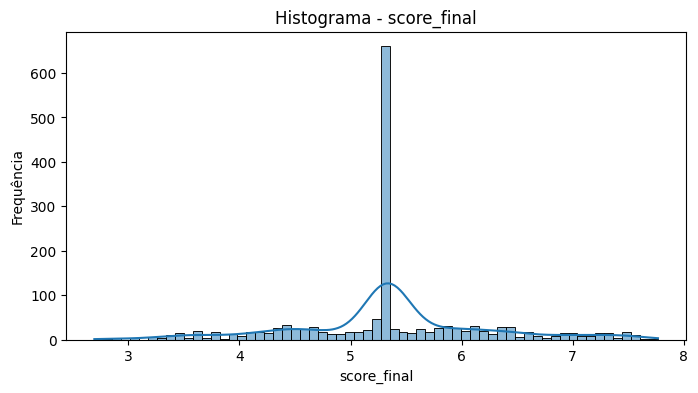

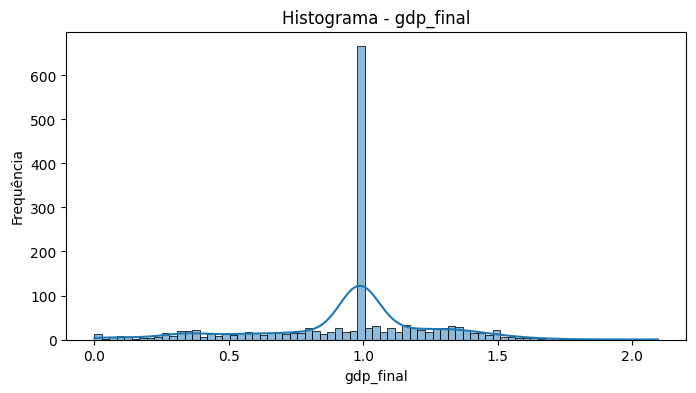

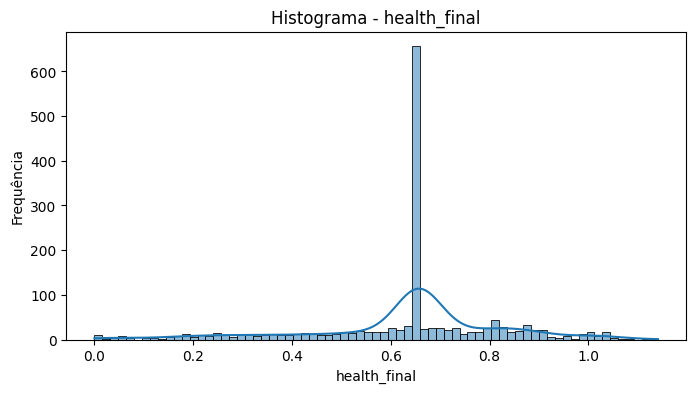

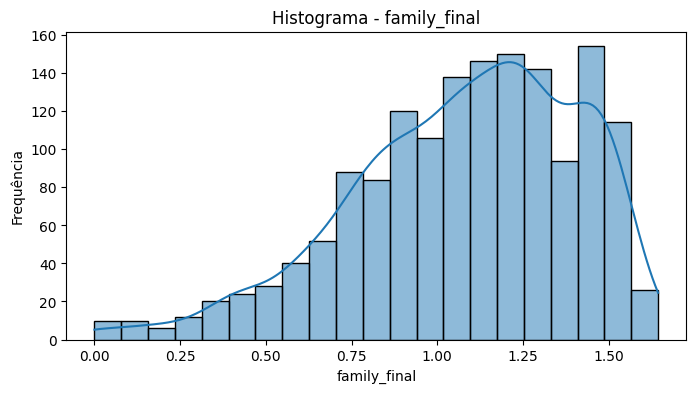

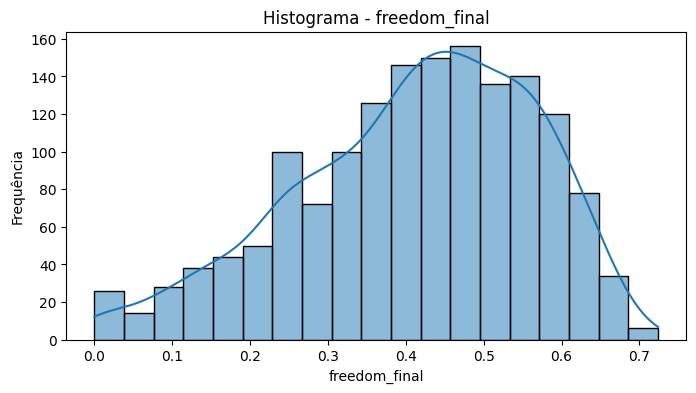

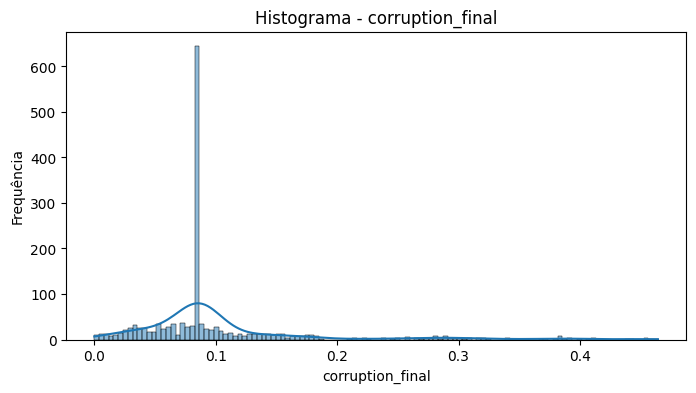

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in colunas_numericas:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Histograma - {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

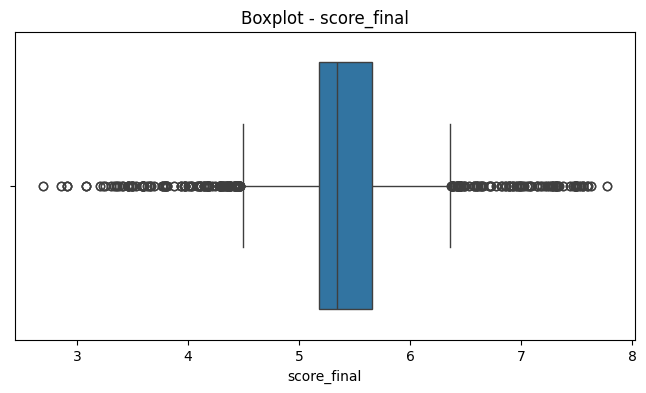

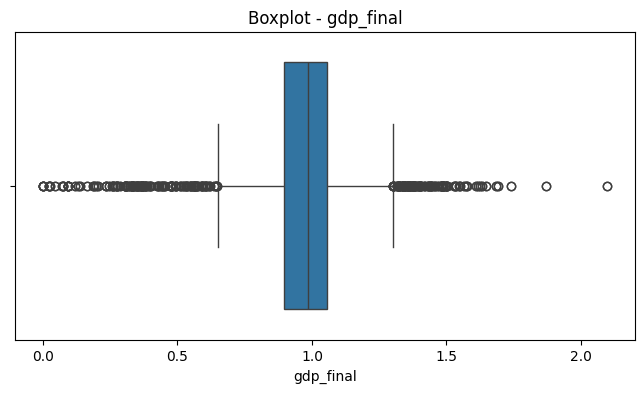

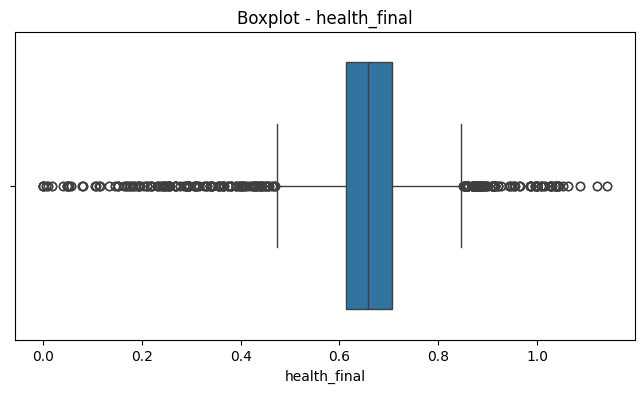

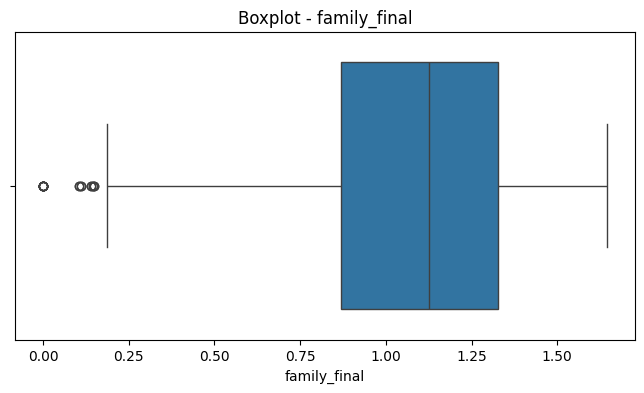

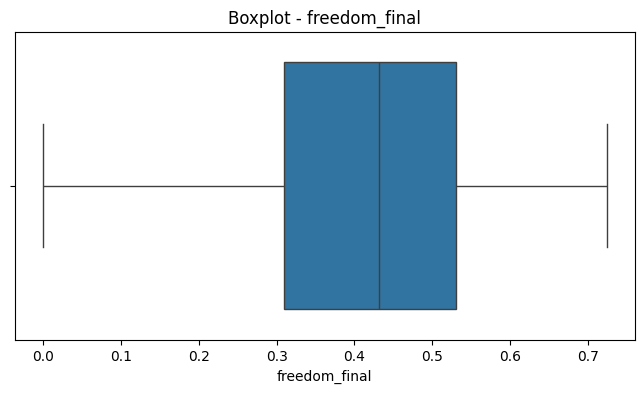

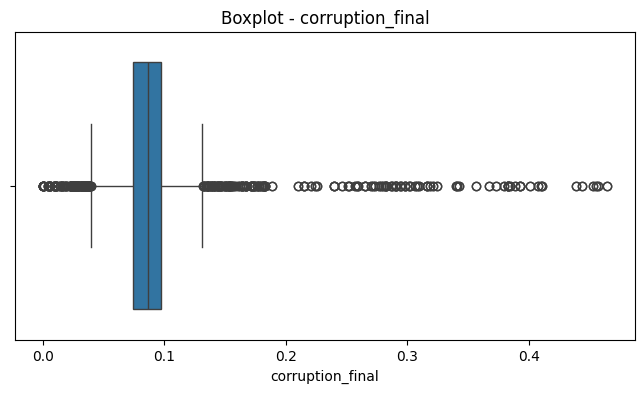

In [26]:
for col in colunas_numericas:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()

# Probabilidade

Foi calculada a probabilidade de score acima da média global.

In [27]:
media_score = df['score_final'].mean()

prob = (df['score_final'] > media_score).mean()

print("Média do score:", media_score)
print("Probabilidade de um país ter score acima da média:", prob)

Média do score: 5.362925831387415
Probabilidade de um país ter score acima da média: 0.29411764705882354


# Probabilidade Condicional

Foi calculada a probabilidade de score alto dado PIB acima da média.

In [28]:
media_gdp = df['gdp_final'].mean()

grupo_pib_alto = df[df['gdp_final'] > media_gdp]

prob_condicional = (grupo_pib_alto['score_final'] > media_score).mean()

print("Média do PIB:", media_gdp)
print("Probabilidade de score alto dado PIB alto:", prob_condicional)

Média do PIB: 0.9507548865750434
Probabilidade de score alto dado PIB alto: 0.33865248226950356


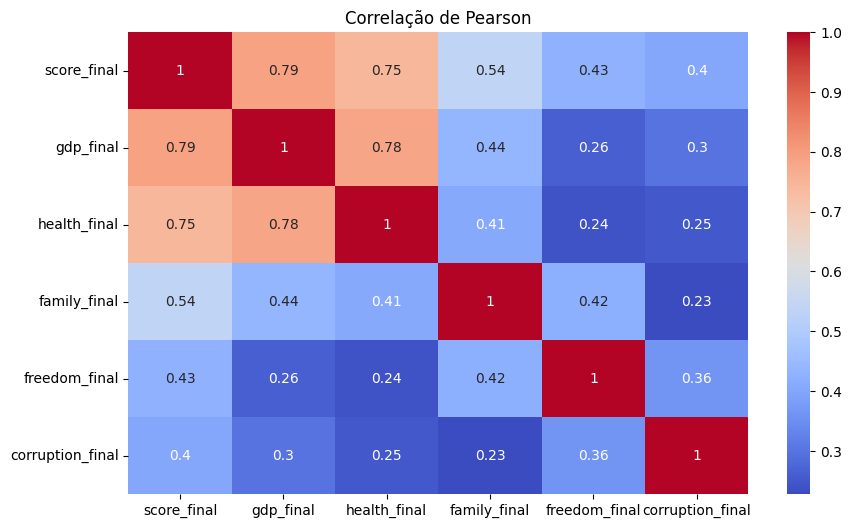

In [29]:
corr_pearson = df[colunas_numericas].corr(method='pearson')

plt.figure(figsize=(10,6))
sns.heatmap(corr_pearson, annot=True, cmap='coolwarm')
plt.title("Correlação de Pearson")
plt.show()

# Correlação de Pearson

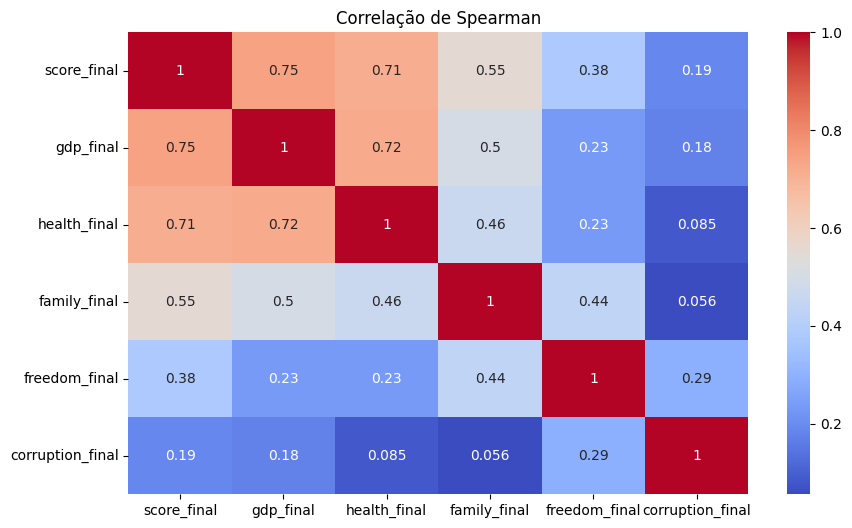

In [30]:
corr_spearman = df[colunas_numericas].corr(method='spearman')

plt.figure(figsize=(10,6))
sns.heatmap(corr_spearman, annot=True, cmap='coolwarm')
plt.title("Correlação de Spearman")
plt.show()

# Associação entre País e Score de Felicidade

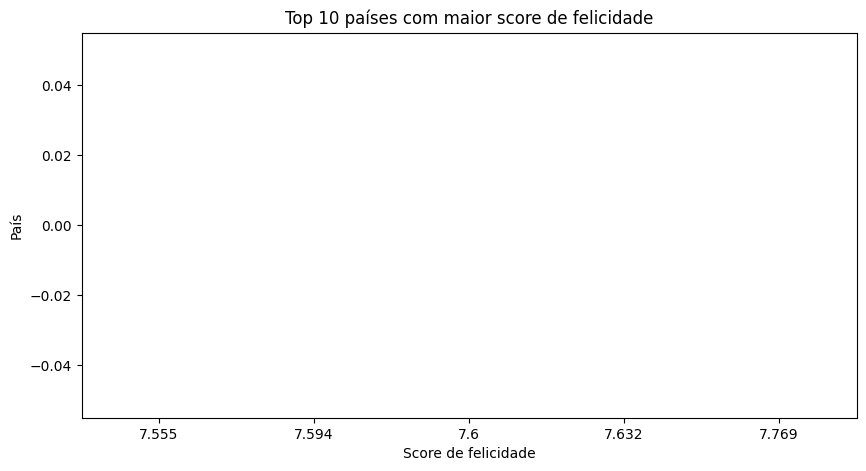

In [31]:
top10 = df[['Country', 'score_final']].sort_values(by='score_final', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x='score_final', y='Country')
plt.title("Top 10 países com maior score de felicidade")
plt.xlabel("Score de felicidade")
plt.ylabel("País")
plt.show()

## Justificativa dos gráficos

Histogramas foram escolhidos para mostrar distribuição e frequência.

Boxplots foram usados para identificar dispersão e outliers.

Heatmaps foram utilizados para evidenciar relações entre variáveis numéricas.

Barplot foi usado para comparação entre países.

In [32]:
print("INSIGHTS FINAIS DA ANÁLISE\n")

print(f"Média global de felicidade: {df['score_final'].mean():.2f}")
print(f"Probabilidade de score acima da média: {((df['score_final'] > df['score_final'].mean()).mean()*100):.2f}%")

print("\nCorrelação com score de felicidade:")
print(corr_pearson['score_final'].sort_values(ascending=False))

INSIGHTS FINAIS DA ANÁLISE

Média global de felicidade: 5.36
Probabilidade de score acima da média: 29.41%

Correlação com score de felicidade:
score_final         1.000000
gdp_final           0.791358
health_final        0.746153
family_final        0.536210
freedom_final       0.429072
corruption_final    0.401163
Name: score_final, dtype: float64


In [33]:
print("Resumo final da análise")
print("-"*40)
print("Média global de felicidade:", round(df['score_final'].mean(), 2))
print("Mediana global de felicidade:", round(df['score_final'].median(), 2))
print("Probabilidade de score acima da média:", round(((df['score_final'] > df['score_final'].mean()).mean())*100, 2), "%")
print("Probabilidade de score alto dado PIB alto:", round(prob_condicional*100, 2), "%")
print("\nCorrelação com score_final:")
print(corr_pearson['score_final'].sort_values(ascending=False))

Resumo final da análise
----------------------------------------
Média global de felicidade: 5.36
Mediana global de felicidade: 5.34
Probabilidade de score acima da média: 29.41 %
Probabilidade de score alto dado PIB alto: 33.87 %

Correlação com score_final:
score_final         1.000000
gdp_final           0.791358
health_final        0.746153
family_final        0.536210
freedom_final       0.429072
corruption_final    0.401163
Name: score_final, dtype: float64




## Relatório Final de Insights

Os países com maior PIB tendem a apresentar maiores índices de felicidade.

A média global de felicidade mostrou que poucos países estão acima da média.

A correlação positiva entre PIB e score indica forte influência econômica no bem-estar.

A distribuição apresentou leve assimetria.